In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
#Static Model :Data Collection

import os
import cv2
import numpy as np
import mediapipe as mp
import re

CLASSES = list("abcdefghijklmnopqrstuvwxyz")[:26]  # A–Z
SAMPLES_PER_CLASS = 300
SAVE_DIR = "static_data"   #directory name for all static signs

#  Creating folders for each alphabet
for alpha in CLASSES:
    os.makedirs(os.path.join(SAVE_DIR, alpha), exist_ok=True)

# MediaPipe 
mp_hands = mp.solutions.hands
hand_detector = mp_hands.Hands(False,1,1,0.5,0.5)  #image mode,maximum,numer of hand,min confidece,max confidece

# Preprocess landmarks
def preprocess_landmarks(landmarks):
    coords = []
    for p in landmarks:
        coords.append([p.x, p.y, p.z])
    coords = np.array(coords, dtype=float)
    # center on wrist
    for i in range(len(coords)):
        coords[i] = coords[i] - coords[0]
    norm = np.linalg.norm(coords) #normalize
    coords = coords / (norm + 1e-6)
    # rotate so finger is up
    v = coords[9][:2]
    angle = np.arctan2(v[1], v[0])
    needed = np.pi/2 - angle
    c = np.cos(needed)
    s = np.sin(needed)
    for i in range(len(coords)):
        x, y = coords[i][0], coords[i][1]
        coords[i][0] = x * c - y * s
        coords[i][1] = x * s + y * c
    return coords.flatten()

# Augmentation
# I did augmentation on the existing data to improve the robustness and generalization of the data.
def augmentation(arr):
    arr3 = arr.reshape(21,3)
    aug_list = []
    # rotate +10 and -10
    for deg in [10, -10]:
        theta = deg * np.pi / 180
        c = np.cos(theta)
        s = np.sin(theta)
        new = []
        for p in arr3:
            x, y, z = p
            new_x = x * c - y * s
            new_y = x * s + y * c
            new.append([new_x, new_y, z])
        aug_list.append(np.array(new).flatten())
    # gaussian noise
    noise = np.random.randn(arr.shape[0]) * 0.02
    aug_list.append(arr + noise)
    return aug_list

# Webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Camera is not opening!!")
    exit()

print("Starting 3 2 1...Data collection initiated successfully!!!")   #remember to press q to quit if any probs

for alpha in CLASSES:
    class_dir = os.path.join(SAVE_DIR, alpha)
    base_files = [f for f in os.listdir(class_dir)
                  if re.match(r"^sample_\d{3}\.npy$", f)]
    if len(base_files) >= SAMPLES_PER_CLASS:
        print(f"Skipping '{alpha.upper()}': already has {len(base_files)} base samples.")
        continue
        
        
    input(f"\nHold it!! '{alpha.upper()}'. Press Enter  {SAMPLES_PER_CLASS} samples...")
    valid_samples_collected = 0
# r- bool,track if frame captured/ f-frame of the cam
    while valid_samples_collected < SAMPLES_PER_CLASS:
        r, f = cap.read()
        if not r:
            continue
        f = cv2.flip(f, 1)  #mirror view,easy to view
        rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
        results = hand_detector.process(rgb)

        if results.multi_hand_landmarks:
            lm = results.multi_hand_landmarks[0].landmark  #extract the 21 points of the hand using MP
            processed_lm = preprocess_landmarks(lm)           # Preprocess
            fname = f"sample_{valid_samples_collected:03d}.npy"
            path = os.path.join(SAVE_DIR, alpha, fname)
            np.save(path, processed_lm)
            # Save augmentations - i is index and a is each aug sample
            for i, a in enumerate(augmentation(processed_lm)):
                aug_name = f"sample_{valid_samples_collected:03d}_aug{i}.npy"
                np.save(os.path.join(SAVE_DIR, alpha, aug_name), a)
            valid_samples_collected += 1
            cv2.putText(f, f"Saved {alpha.upper()} [{valid_samples_collected}/{SAMPLES_PER_CLASS}]",
                        (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        else:
            cv2.putText(f, f"Show '{alpha.upper()}' (hand not detected)",
                        (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        cv2.imshow("Data Collector", f)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("Exiting since u commanded for it!!")
            cap.release()
            cv2.destroyAllWindows()
            hand_detector.close()
            exit()

print("Data collection completed!  Yay!!!!")
cap.release()
cv2.destroyAllWindows()
hand_detector.close()

Starting 3 2 1...Data collection initiated successfully!!!
Skipping 'A': already has 300 base samples.
Skipping 'B': already has 300 base samples.
Skipping 'C': already has 300 base samples.
Skipping 'D': already has 300 base samples.
Skipping 'E': already has 300 base samples.
Skipping 'F': already has 300 base samples.
Skipping 'G': already has 300 base samples.
Skipping 'H': already has 300 base samples.
Skipping 'I': already has 300 base samples.
Skipping 'J': already has 300 base samples.
Skipping 'K': already has 300 base samples.
Skipping 'L': already has 300 base samples.
Skipping 'M': already has 300 base samples.
Skipping 'N': already has 300 base samples.
Skipping 'O': already has 300 base samples.
Skipping 'P': already has 300 base samples.
Skipping 'Q': already has 300 base samples.
Skipping 'R': already has 300 base samples.
Skipping 'S': already has 300 base samples.
Skipping 'T': already has 300 base samples.
Skipping 'U': already has 300 base samples.
Skipping 'V': alr

Found matching classes,data seems to already exist ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Training samples: 24960, Validation samples: 6240


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 21, 64)              │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 21, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 10, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 10, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 5, 256)              │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 5, 256)              │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 26)                  │           3,354 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161,946 (632.60 KB)

 Trainable params: 161,050 (629.10 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6442 - loss: 1.2213 - val_accuracy: 0.7769 - val_loss: 0.6611 - learning_rate: 0.0010
Epoch 2/50
 15/780 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9049 - loss: 0.3258

C:\Users\ganes\anaconda3\envs\mp_env\lib\site-packages\keras\src\callbacks\callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `loss_validation` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


780/780 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8987 - loss: 0.3284 - val_accuracy: 0.4127 - val_loss: 2.9032 - learning_rate: 0.0010
Epoch 3/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9111 - loss: 0.2770 - val_accuracy: 0.5511 - val_loss: 1.5448 - learning_rate: 0.0010
Epoch 4/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9209 - loss: 0.2382 - val_accuracy: 0.6397 - val_loss: 1.3325 - learning_rate: 0.0010
Epoch 5/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9265 - loss: 0.2185 - val_accuracy: 0.7639 - val_loss: 0.6465 - learning_rate: 0.0010
Epoch 6/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9311 - loss: 0.1980 - val_accuracy: 0.6144 - val_loss: 1.8376 - learning_rate: 0.0010
Epoch 7/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9366 - loss: 0.1830 - val_accuracy: 0.8795 - val_loss: 0.4042 - learning_rate: 0.0010
Epoch 8/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9389 - loss: 0.1734 - val_accurac

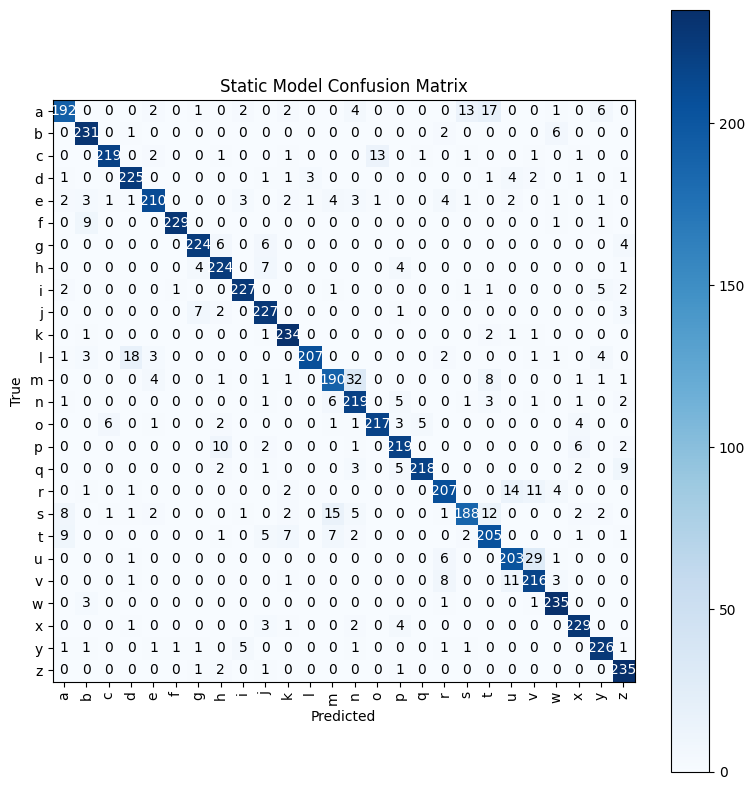

In [2]:
#Static Model -Model training
import os
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

DATA_DIR = "static_data"
test_ratio = 0.2
batch_size = 32
epochs = 50
rand_seed = 42

# Data load
classes = []
for d in os.listdir(DATA_DIR):
    if os.path.isdir(os.path.join(DATA_DIR, d)):
        classes.append(d)
classes.sort()
num_classes = len(classes)
print("Found matching classes,data seems to already exist", classes)

class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

X_list = []
y_list = []
for idx in range(len(classes)):
    cls = classes[idx]
    folder = os.path.join(DATA_DIR, cls)
    for file in os.listdir(folder):
        if file.endswith('.npy'):
            arr = np.load(os.path.join(folder, file))  
            X_list.append(arr)
            y_list.append(idx)

X = np.array(X_list)
y = np.array(y_list)         

#  Reshape to (21, 3) fortraining the cnn model
X = X.reshape(-1, 21, 3)

# data split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=test_ratio, stratify=y, random_state=rand_seed
)
print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")

# Model construction
def oneD_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(21, 3)),
        layers.Conv1D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(),

        layers.Conv1D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(),

        layers.Conv1D(256, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = oneD_cnn_model()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.summary()


early_stop = callbacks.EarlyStopping(patience=7, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='loss_validation', factor=0.5,
                                        patience=3, min_lr=1e-5)

# training
history = model.fit(X_train, y_train,validation_data=(X_val, y_val),epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop, reduce_lr]
)

# model evaluation
loss_validation, accuracy_validation = model.evaluate(X_val, y_val)
print(f"\n Validation Accuracy of the static CNN model is : {accuracy_validation*100:.2f}%")




preds = model.predict(X_val)
pred_labels = []
for i in range(len(preds)):
    pred_labels.append(np.argmax(preds[i]))

print("\nClassification Report of the sttaic model:")
print(classification_report(y_val, pred_labels, target_names=classes))

# confusion matrix
cm = confusion_matrix(y_val, pred_labels)
plt.figure(figsize=(8,8))
plt.imshow(cm, cmap='Blues')
plt.title("Static Model Confusion Matrix")
plt.colorbar()
for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j,i,cm[i,j],ha='center',va='center',
             color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(classes)), classes, rotation=90)
plt.yticks(range(len(classes)), classes)
plt.tight_layout()
plt.show()

model.save("asl_landmark_static_1dcnn_model.h5") #dave the mdoel


In [3]:
#Static Model -Model testing
import cv2
import numpy as np
import tensorflow as tf
import mediapipe as mp

# Load the model
model = tf.keras.models.load_model("asl_landmark_static_1dcnn_model.h5")
letters = []
for c in 'abcdefghijklmnopqrstuvwxyz':
    letters.append(c)
letters.sort()


mp_hands = mp.solutions.hands
hands_detector = mp_hands.Hands(False,1,1,0.5,0.5)

# preprocess the input 

def prepare_landmarks(landmarks):
    pts = []    #congverted landmartk  
    for p in landmarks:
        pts.append([p.x, p.y, p.z])
    pts = np.array(pts, dtype=float)
    w0 = pts[0].copy()    #wrist position
    for i in range(len(pts)):
        pts[i] = pts[i] - w0
    length = np.linalg.norm(pts)
    pts = pts / (length + 1e-6)   #scaling
    vx, vy = pts[9][0], pts[9][1]   
    ang = np.arctan2(vy, vx)    
    need = np.pi/2 - ang    #how much needed so that index points upward
    cosv = np.cos(need)
    sinv = np.sin(need)

    #rotating the hand so it's consistently upright, helping with classification regardless of how the hand  originally kept.
    for i in range(len(pts)):
        x, y = pts[i][0], pts[i][1]
        pts[i][0] = x * cosv - y * sinv
        pts[i][1] = x * sinv + y * cosv
    return pts

cap = cv2.VideoCapture(0)
cv2.namedWindow("Live ASL Prediction", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Live ASL Prediction", 800, 600)

if not cap.isOpened():
    print("Check the cam...something not working correctly.")
    exit()

print("q to quit.")

while True:
    r, f = cap.read()
    if not r:
        print("Frame not captured.")
        break

    f = cv2.flip(f, 1)
    rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)  #coonvert frame to rgb (mediapipe requires this format) 
    results = hands_detector.process(rgb)    

    if results.multi_hand_landmarks:
        lm = results.multi_hand_landmarks[0].landmark
        coords = preprocess_landmarks(lm)  # shape: (21, 3)
        input_tensor = coords.reshape(1, 21, 3)  #batch=1

        prediction = model.predict(input_tensor, verbose=0)
        pred_idx = np.argmax(prediction)
        pred_label = classes[pred_idx]
        confidence = prediction[0][pred_idx]

        # Dsiplay the prediction and confidence in screen
        cv2.putText(f, f"{pred_label.upper()} ({confidence*100:.1f}%)",
                    (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2)
        mp.solutions.drawing_utils.draw_landmarks(
            f, results.multi_hand_landmarks[0], mp_hands.HAND_CONNECTIONS)
    else:
        cv2.putText(f, "No hand detected",
                    (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2)

    cv2.imshow("Live ASL Prediction", f)

    # Exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


q to quit.


In [ ]:
#Dynamic

In [4]:
#Dynamic Model -Data Collection
import os
import cv2
import numpy as np
import mediapipe as mp


phrases = ["hello", "thank_you", "yes", "no", "please","sorry", "good_morning", "good_night", "how_are_you", "congratulations"]

#Default samples per phrase
def_samples = 20
# Increased target for these specific phrases  
#these are similar hand gesture and so more data required.
enh_phrases = {"thank_you", "good_morning", "congratulations"}
targets = {}
for p in phrases:
    if p in enh_phrases:
        targets[p] = 30
    else:
        targets[p] = def_samples

fps = 30  # frames per sample
output_dir = "dyn_data_twohand"  #store the samples collected through webcam

# Ensure folders exist
for phrase in phrases:
    os.makedirs(os.path.join(output_dir, phrase), exist_ok=True)

# MediaPipe init
hands = mp_hands.Hands(False,2,1,0.5,0.5)   #-> static image mdoe,max hands,min det confidence,min tracking confidence

# Landmark preprocessing 
def preprocess_two_hands(multiple_landmarks):
    
    def proc(lm):
        
        coordinates = np.array([[pt.x, pt.y, pt.z] for pt in lm], dtype=np.float32)
        coordinates -= coordinates[0]
        coordinates /= (np.linalg.norm(coordinates) + 1e-6)
        v = coordinates[9, :2]
        rot = np.pi/2 - np.arctan2(v[1], v[0])
        c, s = np.cos(rot), np.sin(rot)
        xy = coordinates[:, :2]
        coordinates[:, 0] = xy[:, 0] * c - xy[:, 1] * s
        coordinates[:, 1] = xy[:, 0] * s + xy[:, 1] * c
        return coordinates.flatten()


    hand_arranged = sorted(multiple_landmarks,key=lambda hl: np.mean([pt.x for pt in hl.landmark]))
    vectors = [proc(hl.landmark) for hl in hand_arranged]
    while len(vectors) < 2:
        vectors.append(np.zeros(63, dtype=np.float32))
    return np.concatenate(vectors)

def padding(sequence, length):
    if len(sequence) >= length:
        return sequence[:length]
    last = sequence[-1]
    while len(sequence) < length:
        sequence.append(last)
    return sequence




# Start video capture
future_exit = False
vid_capture = cv2.VideoCapture(0)
if not vid_capture.isOpened():
    print("Problem with camera +_+")
    hands.close()
    exit()


# Recording loop
for phrase in phrases:
    folder = os.path.join(output_dir, phrase)
    existing = [f for f in os.listdir(folder) if f.endswith(".npy")]
    current_count = len(existing)
    target = targets[phrase]


    if current_count >= target:
        print(f"Skipping '{phrase}' already have {current_count}/{target} samples.")
        continue

    needed = target - current_count
    print(f"\nNeed {needed} more samples for '{phrase}' (have {current_count}, want {target}).")
    input("Press Enter to start recording... ")

    for i in range(current_count, target):
        sequence = []
        print(f"Recording '{phrase}' sample {i+1}/{target}")
        for _ in range(fps):
            r, frame = vid_capture.read()
            if not r:
                continue
            frame = cv2.flip(frame, 1)
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            r1 = hands.process(rgb)
            if r1.multi_hand_landmarks:
                vector_temp = preprocess_two_hands(r1.multi_hand_landmarks)
                if vector_temp.shape != (126,):
                    vector_temp = np.zeros(126, dtype=np.float32)
            else:
                vector_temp = sequence[-1] if sequence and sequence[-1].shape == (126,) else np.zeros(126, dtype=np.float32)
            sequence.append(vector_temp)
            cv2.putText(frame, f"{phrase} {len(sequence)}/{fps}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.imshow("Recording", frame)
            if cv2.waitKey(30) & 0xFF == ord('q'):
                future_exit = True
                break
        cv2.destroyWindow("Recording")

        if future_exit:
            break

        sequence = padding(sequence, fps)
        arr = np.stack(sequence, 0)
        save_path = os.path.join(folder, f"sample_{i:03d}.npy")
        np.save(save_path, arr)
        print(f"   Saved in the path: {save_path}")

    if future_exit:
        print("Recording stopped by the Instructor!!.")
        break

print("All done!!!")
vid_capture.release()
cv2.destroyAllWindows()
hands.close()





#-------------------------------------------------------------------------------------------------------

#Dynamic Model -Model training

import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight     
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


output_dir= "dyn_data_twohand"    
model_location= "asl_dynamic_twohand_lstm.h5"
fps= 30                    
F = 126                   
test_sze= 0.2
rand_seed = 42
batch_sze= 16
epochs = 50

X, y = [], []
for phrase in sorted(os.listdir(output_dir)):
    phrases_dir = os.path.join(output_dir, phrase)

    if not os.path.isdir(phrases_dir): 
        continue

    for fn in os.listdir(phrases_dir):
        if not fn.endswith(".npy"): 
            continue
        sequence = np.load(os.path.join(phrases_dir, fn))
        if sequence.shape != (fps, F):
            print(f"Skipping {phrase}/{fn}, shape {sequence.shape}")
            continue
        X.append(sequence)
        y.append(phrase)

if not X:
    raise RuntimeError("No valid data found in " + output_dir)

X = np.stack(X, axis=0)
y = np.array(y)

#label encoder
classes = sorted(set(y))
cls_to_idx = {c:i for i,c in enumerate(classes)}
y_idx = np.array([cls_to_idx[c] for c in y], dtype=np.int32)

#val/train split
X_train, X_val, y_train, y_val = train_test_split(X, y_idx,test_size=test_sze,stratify=y_idx, random_state=rand_seed)

print(f"Train samples: {X_train.shape[0]}, Val samples: {X_val.shape[0]}")
print("Classes:", classes)

#class weights
balanced_weights = compute_class_weight(class_weight='balanced',classes=np.arange(len(classes)),y=y_train)

# Manually bump the 3 under-performing classes:
for cname, factor in [("thank_you",      2.0),("good_morning",   1.2),("congratulations",1.5)]:
    
    idx = cls_to_idx[cname]
    balanced_weights[idx] *= factor

class_weight = {i: float(w) for i, w in enumerate(balanced_weights)}
print("Class weights:", {classes[i]: class_weight[i] for i in class_weight})

#model construction 
def build_model():

    m = models.Sequential()
    m.add(layers.Input(shape=(fps, F)))
    m.add(layers.LSTM(128, return_sequences=True))
    m.add(layers.Dropout(0.5))
    m.add(layers.LSTM(64))
    m.add(layers.Dropout(0.5))
    m.add(layers.Dense(64, activation='relu'))
    m.add(layers.Dropout(0.5))
    m.add(layers.Dense(len(classes), activation='softmax'))
    return m

if os.path.exists(model_location):
    print("Loading the existing model...")
    model = tf.keras.models.load_model(model_location)
else:
    print("Building a new model...")
    model = build_model()

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

#callback
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)   

#training the  model
history = model.fit(X_train, y_train,validation_data=(X_val, y_val),epochs=epochs,batch_size=batch_sze,class_weight=class_weight,callbacks=[early_stop, reduce_lr])

# evaluation
val_loss, val_acc = model.evaluate(X_val, y_val, batch_size=batch_sze)
print(f"\nValidation accuracy of dynami model : {val_acc*100:.2f}%")

# evaltrics
from sklearn.metrics import classification_report
y_pred = np.argmax(model.predict(X_val), axis=1)
print("\nClassification Report of the dyn model:")
print(classification_report(y_val, y_pred, target_names=classes))

model.save(model_location)
print(f"Model saved to {model_location}")



#----------------------------------------------------------------------------------------------------


#Dynamic Model -Model testing
import cv2
import numpy as np
import mediapipe as mp
import tensorflow as tf
from collections import deque

model_location = "asl_dynamic_twohand_lstm.h5"
output_dir= "dyn_data_twohand"   
fps = 30                  
F = 126                

model = tf.keras.models.load_model(model_location)

classes = sorted([d for d in os.listdir(output_dir) if os.path.isdir(os.path.join(output_dir,d))])

# MediaPipe
mp_hands = mp.solutions.hands
hands    = mp_hands.Hands(False,2,1,0.5,0.5)

# Preprocessing
def preprocess_two_hands(multiple_landmarks):
    def proc(lm):
        coordinates = np.array([[p.x, p.y, p.z] for p in lm], dtype=np.float32)
        coordinates -= coordinates[0]
        coordinates /= (np.linalg.norm(coordinates) + 1e-6)
        v = coordinates[9,:2]
        rot = (np.pi/2) - np.arctan2(v[1],v[0])
        c,s = np.cos(rot), np.sin(rot)
        xy = coordinates[:,:2]
        coordinates[:,0] = xy[:,0]*c - xy[:,1]*s
        coordinates[:,1] = xy[:,0]*s + xy[:,1]*c
        return coordinates.flatten()
    # sort by x to get left then right
    sorted_hands = sorted(multiple_landmarks, key=lambda hl: np.mean([p.x for p in hl.landmark]))
    vectors = [proc(hl.landmark) for hl in sorted_hands]
    
    while len(vectors)<2:
        vectors.append(np.zeros(63, dtype=np.float32))
    return np.concatenate(vectors)



# buffer
buffer = deque(maxlen=fps)

#webcam
vid_capture = cv2.VideoCapture(0)
cv2.namedWindow("Dynamic ASL", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Dynamic ASL", 800,600)

print("q to quit.")


while True:
    r, frame = vid_capture.read()
    if not r: break

    frame = cv2.flip(frame,1)
    rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    r1   = hands.process(rgb)

    if r1.multi_hand_landmarks:
        vector_temp = preprocess_two_hands(r1.multi_hand_landmarks)

    # Debuggine
        #print("DEBUG: vec.shape =", vec.shape)
        
        if vector_temp.ndim != 1 or vector_temp.shape[0] != F:
            print(f"Skipping cos the vector is invalid shape {vector_temp.shape}")
            continue

        buffer.append(vector_temp)
        mp.solutions.drawing_utils.draw_landmarks(
        frame, r1.multi_hand_landmarks[0], mp_hands.HAND_CONNECTIONS)
    else:
        cv2.putText(frame, "No hands", (10,30),
                cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2)

    
    if len(buffer)==fps:
        sequence = np.stack(buffer, axis=0).reshape(1,fps,F)
        pred = model.predict(sequence, verbose=0)[0]
        idx  = np.argmax(pred)
        ph   = classes[idx].replace("_"," ").title()
        conf = pred[idx]
        cv2.putText(frame, f"{ph} ({conf*100:.1f}%)", (10,60),
                    cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)

    cv2.imshow("Dynamic ASL", frame)
    if cv2.waitKey(1)&0xFF==ord('q'):
        break

vid_capture.release()
cv2.destroyAllWindows()
hands.close()

Skipping 'hello' already have 20/20 samples.
Skipping 'thank_you' already have 30/30 samples.
Skipping 'yes' already have 20/20 samples.
Skipping 'no' already have 20/20 samples.
Skipping 'please' already have 20/20 samples.
Skipping 'sorry' already have 20/20 samples.
Skipping 'good_morning' already have 30/30 samples.
Skipping 'good_night' already have 20/20 samples.
Skipping 'how_are_you' already have 20/20 samples.
Skipping 'congratulations' already have 30/30 samples.
All done!!!
Train samples: 184, Val samples: 46
Classes: ['congratulations', 'good_morning', 'good_night', 'hello', 'how_are_you', 'no', 'please', 'sorry', 'thank_you', 'yes']
Class weights: {'congratulations': 1.1500000000000001, 'good_morning': 0.92, 'good_night': 1.15, 'hello': 1.15, 'how_are_you': 1.15, 'no': 1.15, 'please': 1.15, 'sorry': 1.15, 'thank_you': 1.5333333333333334, 'yes': 1.15}
Loading the existing model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 128)             │         130,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 30, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 184,778 (721.79 KB)

 Trainable params: 184,778 (721.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9618 - loss: 0.2469 - val_accuracy: 0.9130 - val_loss: 0.5795 - learning_rate: 0.0010
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9720 - loss: 0.1158 - val_accuracy: 0.9348 - val_loss: 0.4899 - learning_rate: 0.0010
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9574 - loss: 0.1384 - val_accuracy: 0.9348 - val_loss: 0.5378 - learning_rate: 0.0010
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9900 - loss: 0.0819 - val_accuracy: 0.9348 - val_loss: 0.5862 - learning_rate: 0.0010
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9833 - loss: 0.0906 - val_accuracy: 0.9348 - val_loss: 0.5371 - learning_rate: 0.0010
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9895 - loss: 0.0766 - val_accuracy: 0.9130 - val_loss: 0.5782 - learning_rate: 5.0000e-04
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9941 - loss: 0.0468 - val


Classification Report of the dyn model:
                 precision    recall  f1-score   support

congratulations       0.83      0.83      0.83         6
   good_morning       0.86      1.00      0.92         6
     good_night       1.00      0.75      0.86         4
          hello       1.00      1.00      1.00         4
    how_are_you       1.00      1.00      1.00         4
             no       0.80      1.00      0.89         4
         please       1.00      1.00      1.00         4
          sorry       1.00      1.00      1.00         4
      thank_you       1.00      0.83      0.91         6
            yes       1.00      1.00      1.00         4

       accuracy                           0.93        46
      macro avg       0.95      0.94      0.94        46
   weighted avg       0.94      0.93      0.93        46

Model saved to asl_dynamic_twohand_lstm.h5
q to quit.


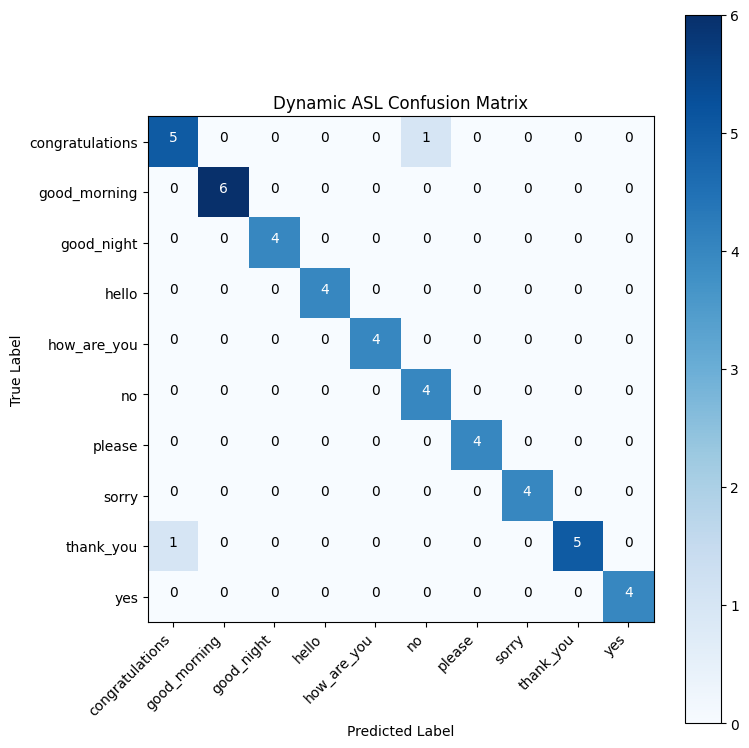

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix
import tensorflow as tf

model = tf.keras.models.load_model("asl_dynamic_twohand_lstm.h5")


y_prob = model.predict(X_val, verbose=0)      # shape: (N_samples, N_classes)
y_pred = np.argmax(y_prob, axis=1)            # predicted class indices
y_true = y_val                                # true class indices


cm = confusion_matrix(y_true, y_pred)         # shape: (N_classes, N_classes)


def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title("Dynamic ASL Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

 
    fmt = 'd'
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(cm, classes)


In [ ]:
#Hybrid

In [5]:
#Waiting time included
import os
import cv2
import time
import numpy as np
import mediapipe as mp
import tensorflow as tf
from collections import deque

static_model_path   = "asl_landmark_1dcnn_model.h5"
dynamic_model_path  = "asl_dynamic_twohand_lstm.h5"
T                   = 30       # frames in dynamic window
F_dyn               = 126      # dynamic feature dim 
MOTION_THRESHOLD    = 0.1      # wrist‐travel threshold
HOLD_DURATION       = 4.0      # seconds to hold dynamic phrase

# Load models
static_model  = tf.keras.models.load_model(static_model_path)
dynamic_model = tf.keras.models.load_model(dynamic_model_path)
static_classes  = sorted(os.listdir("data1"))            
dynamic_classes = sorted(os.listdir("dyn_data_twohand")) 


#MediaPipe 
mp_hands = mp.solutions.hands
hands    = mp_hands.Hands(False,2,1,0.5,0.5)

# Preprocess 
def preprocess_two_hands(lm_list):
    # inner helper for one hand
    def proc(lm):
        coords = []
        for p in lm:
            coords.append([p.x, p.y, p.z])
        # convert to numpy for some ops
        arr = np.array(coords, dtype=np.float32)
        # subtract wrist
        wx, wy, wz = arr[0][0], arr[0][1], arr[0][2]
        for i in range(len(arr)):
            arr[i][0] = arr[i][0] - wx
            arr[i][1] = arr[i][1] - wy
            arr[i][2] = arr[i][2] - wz
        # manual norm calculation
        total = 0.0
        for i in range(len(arr)):
            total += arr[i][0]**2 + arr[i][1]**2 + arr[i][2]**2
        total = total ** 0.5
        total = total + 1e-6
        for i in range(len(arr)):
            arr[i][0] = arr[i][0] / total
            arr[i][1] = arr[i][1] / total
            arr[i][2] = arr[i][2] / total
        # rotation
        dx = arr[9][0]
        dy = arr[9][1]
        angle = (np.pi/2) - np.arctan2(dy, dx)
        cos_a = np.cos(angle)
        sin_a = np.sin(angle)
        rotated = []
        for i in range(len(arr)):
            x, y, z = arr[i][0], arr[i][1], arr[i][2]
            new_x = x * cos_a - y * sin_a
            new_y = x * sin_a + y * cos_a
            rotated.append([new_x, new_y, z])
        # flatten
        flat = []
        for triple in rotated:
            for val in triple:
                flat.append(val)
        return flat

    # sort hands by average x
    hand_x_means = []
    for h in lm_list:
        sum_x = 0.0
        count = 0
        for p in h.landmark:
            sum_x += p.x
            count += 1
        hand_x_means.append((sum_x / count, h))
    # simple bubble-like sort
    for i in range(len(hand_x_means)):
        for j in range(0, len(hand_x_means)-i-1):
            if hand_x_means[j][0] > hand_x_means[j+1][0]:
                tmp = hand_x_means[j]
                hand_x_means[j] = hand_x_means[j+1]
                hand_x_means[j+1] = tmp

    vecs = []
    for pair in hand_x_means:
        lm = pair[1].landmark
        vecs.append(proc(lm))
    # pad with zeros if only one hand
    while len(vecs) < 2:
        zeros = []
        for _ in range(63):
            zeros.append(0.0)
        vecs.append(zeros)
    # combine
    final = []
    for lst in vecs:
        for x in lst:
            final.append(x)
    return np.array(final, dtype=np.float32)

# Open webcam & init buffers
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Probs with the camera!")
    hands.close()
    exit()

dyn_buffer    = deque(maxlen=T)
wrist_buffer  = deque(maxlen=T)
last_dyn_time = 0.0
last_phrase   = ""

print("hybrid mode running!!! Press q to quit.")

while True:
    r, frame = cap.read()
    if not r:
        break
    frame = cv2.flip(frame,1)
    rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    res   = hands.process(rgb)

    # Draw hand skeletons
    if res.multi_hand_landmarks:
        for hl in res.multi_hand_landmarks:
            mp.solutions.drawing_utils.draw_landmarks(frame, hl, mp_hands.HAND_CONNECTIONS)

    # Update dynamic buffers
    if res.multi_hand_landmarks:
        vec = preprocess_two_hands(res.multi_hand_landmarks)
        dyn_buffer.append(vec)
        w = res.multi_hand_landmarks[0].landmark[0]
        wrist_buffer.append((w.x,w.y))
    else:
        if dyn_buffer:   dyn_buffer.append(dyn_buffer[-1])
        if wrist_buffer: wrist_buffer.append(wrist_buffer[-1])

    # waiting till we have T frames
    if len(wrist_buffer)==T:
        # calc wrist travel-> tot eucl dist wrist moved over last T frames
        #Main Logic:
        #High value->dynamic sign
        #Low value->static sign
        travel = sum(np.hypot(wrist_buffer[i][0]-wrist_buffer[i-1][0],
                     wrist_buffer[i][1]-wrist_buffer[i-1][1])
            for i in range(1,T)
        )

        now = time.time()
        #this is to display the identified word for a set period of time(prevents the model from keeping on scanning and displaying no results-makes it practical for real world applications)
        if now - last_dyn_time < HOLD_DURATION:
            cv2.putText(frame, last_phrase, (10,60),
                        cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2)
        
        
        else:
            # decide dynamic vs static


            if travel > MOTION_THRESHOLD:
                # dynamic gestures detection
                seq = np.stack(dyn_buffer,0).reshape(1,T,F_dyn)
                p_dyn = dynamic_model.predict(seq,verbose=0)[0]   #prob of each phrae
                i_dyn = np.argmax(p_dyn)   #index of the most probable phrase
                ph    = dynamic_classes[i_dyn].replace("_"," ").title()
                last_phrase   = f"{ph} ({p_dyn[i_dyn]*100:.1f}%)"  #displaying the phrase and the confidence value as well
                last_dyn_time = now
                cv2.putText(frame, last_phrase, (10,60),
                            cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2)
                # clear and reset so next gesture starts fresh
                dyn_buffer.clear()
                wrist_buffer.clear()


            else:
                # static gestures detection
                if res.multi_hand_landmarks:
                    lm = res.multi_hand_landmarks[0].landmark
                    coords = np.array([[p.x,p.y,p.z] for p in lm],dtype=np.float32)
                    coords -= coords[0]
                    coords /= (np.linalg.norm(coords)+1e-6)
                    v = coords[9,:2]
                    rot = (np.pi/2)-np.arctan2(v[1],v[0])
                    c,s = np.cos(rot), np.sin(rot)
                    xy = coords[:,:2]
                    coords[:,0] = xy[:,0]*c - xy[:,1]*s
                    coords[:,1] = xy[:,0]*s + xy[:,1]*c

                    inp_stat = coords.reshape(1,21,3)
                    p_stat   = static_model.predict(inp_stat,verbose=0)[0]
                    i_stat   = np.argmax(p_stat)
                    txt = f"{static_classes[i_stat].upper()} ({p_stat[i_stat]*100:.1f}%)"
                    cv2.putText(frame, txt, (10,30),
                                cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)

    cv2.imshow("Hybrid ASL", frame)
    if cv2.waitKey(1)&0xFF==ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
hands.close()



hybrid mode running!!! Press q to quit.


In [7]:
import os
import cv2
import time
import numpy as np
import mediapipe as mp
import tensorflow as tf
from collections import deque

# —– user parameters —–
static_model_path   = "asl_landmark_1dcnn_model.h5"
dynamic_model_path  = "asl_dynamic_twohand_lstm.h5"
T                   = 30        # frames in dynamic window
F_dyn               = 126       # dynamic feature dim
MOTION_THRESHOLD    = 0.1       # wrist‐travel threshold
HOLD_DURATION       = 4.0       # seconds to hold display

# Load models & class‐lists
static_model   = tf.keras.models.load_model(static_model_path)
dynamic_model  = tf.keras.models.load_model(dynamic_model_path)
static_classes = sorted(os.listdir("static_data"))
dynamic_classes= sorted(os.listdir("dyn_data_twohand"))

# MediaPipe hands
mp_hands = mp.solutions.hands
hands    = mp_hands.Hands(static_image_mode=False,max_num_hands=2,min_detection_confidence=0.5,min_tracking_confidence=0.5)

def preprocess_two_hands(lm_list):
    
    def proc(lm):
        arr = np.array([[p.x,p.y,p.z] for p in lm], dtype=np.float32)
        arr -= arr[0]                          # translate wrist→0
        arr /= (np.linalg.norm(arr)+1e-6)     # normalize
        dx,dy = arr[9,0], arr[9,1]
        angle = (np.pi/2) - np.arctan2(dy,dx)
        c,s = np.cos(angle), np.sin(angle)
        xy = arr[:,:2]
        arr[:,:2] = np.stack([xy[:,0]*c - xy[:,1]*s,
                              xy[:,0]*s + xy[:,1]*c], axis=-1)
        return arr.flatten().tolist()

    # sort hands by x‑mean, process each, pad if only one
    hands_sorted = sorted(
        lm_list,
        key=lambda h: np.mean([p.x for p in h.landmark])
    )
    vecs = [proc(h.landmark) for h in hands_sorted]
    if len(vecs)==1:
        vecs.append([0.0]*63)
    return np.array(vecs[0] + vecs[1], dtype=np.float32)


cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Cannot open camera"); hands.close(); exit()

dyn_buffer   = deque(maxlen=T)
wrist_buffer = deque(maxlen=T)
last_dyn_time= 0.0
last_phrase  = ""

#Latency calculation
frame_times       = []
stat_inf_times    = []
dyn_inf_times     = []
stat_confidences  = []
dyn_confidences   = []
stat_count = 0
dyn_count  = 0

print("Hybrid mode running — press 'q' to quit and see metrics.")

while True:
    t0 = time.perf_counter()
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame,1)
    rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    res   = hands.process(rgb)

    # draw hand skeletons
    if res.multi_hand_landmarks:
        for hl in res.multi_hand_landmarks:
            mp.solutions.drawing_utils.draw_landmarks(
                frame, hl, mp_hands.HAND_CONNECTIONS)

    
    if res.multi_hand_landmarks:
        dyn_buffer.append(preprocess_two_hands(res.multi_hand_landmarks))
        w = res.multi_hand_landmarks[0].landmark[0]
        wrist_buffer.append((w.x,w.y))
    else:
        if dyn_buffer:   dyn_buffer.append(dyn_buffer[-1])
        if wrist_buffer: wrist_buffer.append(wrist_buffer[-1])

    # when we have T frames, decide static vs dynamic
    if len(wrist_buffer)==T:
        travel = sum(
            np.hypot(wrist_buffer[i][0]-wrist_buffer[i-1][0],
                     wrist_buffer[i][1]-wrist_buffer[i-1][1])
            for i in range(1,T)
        )
        now = time.time()

        if now - last_dyn_time < HOLD_DURATION:
            cv2.putText(frame, last_phrase, (10,60),
                        cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2)
        else:
            if travel > MOTION_THRESHOLD:
            
                seq = np.stack(dyn_buffer,0).reshape(1,T,F_dyn)
                t1 = time.perf_counter()
                p_dyn = dynamic_model.predict(seq,verbose=0)[0]
                t2 = time.perf_counter()
                dyn_inf_times.append(t2-t1)

                i_dyn = np.argmax(p_dyn); conf = p_dyn[i_dyn]
                dyn_confidences.append(conf); dyn_count += 1

                ph = dynamic_classes[i_dyn].replace("_"," ").title()
                last_phrase   = f"{ph} ({conf*100:.1f}%)"
                last_dyn_time = now
                cv2.putText(frame, last_phrase, (10,60),
                            cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2)

                dyn_buffer.clear()
                wrist_buffer.clear()
            else:
                
                if res.multi_hand_landmarks:
                    lm = res.multi_hand_landmarks[0].landmark
                    coords = np.array([[p.x,p.y,p.z] for p in lm],dtype=np.float32)
                    coords -= coords[0]
                    coords /= (np.linalg.norm(coords)+1e-6)
                    v = coords[9,:2]
                    rot = (np.pi/2)-np.arctan2(v[1],v[0])
                    c,s = np.cos(rot), np.sin(rot)
                    xy = coords[:,:2]
                    coords[:,:2] = np.stack([xy[:,0]*c - xy[:,1]*s,
                                             xy[:,0]*s + xy[:,1]*c], axis=-1)

                    inp = coords.reshape(1,21,3)
                    t1 = time.perf_counter()
                    p_stat = static_model.predict(inp,verbose=0)[0]
                    t2 = time.perf_counter()
                    stat_inf_times.append(t2-t1)

                    i_stat = np.argmax(p_stat); conf = p_stat[i_stat]
                    stat_confidences.append(conf); stat_count += 1

                    txt = f"{static_classes[i_stat].upper()} ({conf*100:.1f}%)"
                    cv2.putText(frame, txt, (10,30),
                                cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)

   
    cv2.imshow("Hybrid ASL", frame)
    t3 = time.perf_counter()
    frame_times.append(t3-t0)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break


cap.release()
cv2.destroyAllWindows()
hands.close()


import numpy as np

print("\n=== Efficiency Metrics ===")
total_frames = len(frame_times)
total_time   = sum(frame_times)
fps          = total_frames/total_time if total_time>0 else 0.0
print(f"Total frames processed:    {total_frames}")
print(f"Overall FPS:              {fps:.2f}")

def summarize(times, name):
    if not times:
        print(f"No {name} inferences were run.")
        return
    a, mn, mx = np.mean(times), np.min(times), np.max(times)
    print(f"{name} inferences: count={len(times)}, avg={a*1000:.2f} ms, "
          f"min={mn*1000:.2f} ms, max={mx*1000:.2f} ms")

summarize(stat_inf_times, "Static")
summarize(dyn_inf_times,  "Dynamic")

print(f"Static predictions count:   {stat_count}")
print(f"Dynamic predictions count:  {dyn_count}")

if stat_confidences:
    print(f"Avg static confidence:    {np.mean(stat_confidences)*100:.1f}%")
if dyn_confidences:
    print(f"Avg dynamic confidence:   {np.mean(dyn_confidences)*100:.1f}%")


Hybrid mode running — press 'q' to quit and see metrics.

=== Efficiency Metrics ===
Total frames processed:    1373
Overall FPS:              23.91
Static inferences: count=117, avg=60.21 ms, min=57.25 ms, max=148.55 ms
Dynamic inferences: count=12, avg=76.89 ms, min=59.54 ms, max=240.97 ms
Static predictions count:   117
Dynamic predictions count:  12
Avg static confidence:    98.0%
Avg dynamic confidence:   81.8%
